In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Carga del dataset (asegúrate de tener el CSV en la misma carpeta que este notebook)
csv_path = "gaming.csv"
assert os.path.exists(csv_path), "No se encontró el archivo Gaming-Trends-2024.csv en el directorio actual."

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Columnas:", list(df.columns))
df.head()

Shape: (4989, 11)
Columnas: ['Date', 'Platform', 'Daily Active Users (DAU)', 'New Registrations', 'Session Duration (minutes)', 'In-game Purchases ($)', 'Social Media Mentions', 'Stream Viewership', 'Revenue', 'Top Genre', 'Influencer Endorsements']


,Date,Platform,Daily Active Users (DAU),New Registrations,Session Duration (minutes),In-game Purchases ($),Social Media Mentions,Stream Viewership,Revenue,Top Genre,Influencer Endorsements
0,2022-04-13,PC,142204,14220,31.266635,60772.724060,7116,85079.542766,87378.407590,Action,0
1,2021-03-17,PC,132314,13231,23.314436,43499.834450,6582,64188.420576,41132.113751,Action,0
2,2019-03-09,VR,111557,11155,33.859334,52178.791314,5572,34385.665788,71787.342041,Simulation,0
3,2021-03-31,Console,132909,13290,80.580010,25085.562444,6619,43129.915707,18639.641156,RPG,0
4,2021-02-04,Mobile,130694,13069,37.270903,55277.074439,6555,69341.389827,63849.959750,Action,0


crear variable de clasificacion umbral, revenue encima de la mediana o percentil 75

In [7]:


# Supongamos que ya cargaste tu dataset en df
# df = pd.read_csv("videojuegos.csv")

# Usamos la mediana como umbral
threshold = df["Revenue"].median()

df["HighRevenue"] = (df["Revenue"] > threshold).astype(int)

print(df[["Revenue", "HighRevenue"]].head())

df.head()

        Revenue  HighRevenue
0  87378.407590            1
1  41132.113751            0
2  71787.342041            1
3  18639.641156            0
4  63849.959750            0


,Date,Platform,Daily Active Users (DAU),New Registrations,Session Duration (minutes),In-game Purchases ($),Social Media Mentions,Stream Viewership,Revenue,Top Genre,Influencer Endorsements,HighRevenue
0,2022-04-13,PC,142204,14220,31.266635,60772.724060,7116,85079.542766,87378.407590,Action,0,1
1,2021-03-17,PC,132314,13231,23.314436,43499.834450,6582,64188.420576,41132.113751,Action,0,0
2,2019-03-09,VR,111557,11155,33.859334,52178.791314,5572,34385.665788,71787.342041,Simulation,0,1
3,2021-03-31,Console,132909,13290,80.580010,25085.562444,6619,43129.915707,18639.641156,RPG,0,0
4,2021-02-04,Mobile,130694,13069,37.270903,55277.074439,6555,69341.389827,63849.959750,Action,0,0


## Support Vector Machine (SVM)

In [ ]:
# --- Features y target ---
features = [
    "Daily Active Users (DAU)",
    "New Registrations",
    "Session Duration (minutes)",
    "In-game Purchases ($)",
    "Social Media Mentions",
    
    "Influencer Endorsements",
    "Platform",
    "Top Genre"
]

X = df[features]
y = df["HighRevenue"]

# --- Separar columnas numéricas y categóricas ---
cat_cols = ["Platform", "Top Genre"]
num_cols = [c for c in X.columns if c not in cat_cols]

# --- Preprocesamiento ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# --- Pipeline completo ---
svm_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
])

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Entrenamiento ---
svm_clf.fit(X_train, y_train)

# --- Predicciones ---
y_pred = svm_clf.predict(X_test)

# --- Evaluación ---
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.72      0.43      0.54       499
           1       0.59      0.84      0.69       499

    accuracy                           0.63       998
   macro avg       0.66      0.63      0.62       998
weighted avg       0.66      0.63      0.62       998

Matriz de confusión:
[[213 286]
 [ 81 418]]


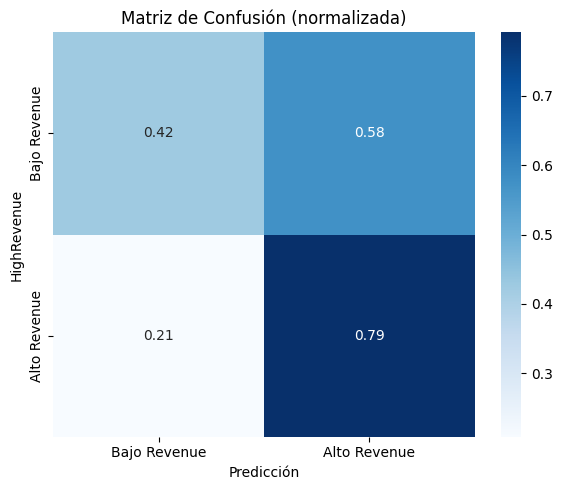

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con etiquetas
plt.figure(figsize=(6, 5))
labels = ['Bajo Revenue', 'Alto Revenue']
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusión (normalizada)")


plt.xlabel('Predicción')
plt.ylabel('HighRevenue')

plt.tight_layout()
plt.show()
